**Table of contents**<a id='toc0_'></a>    
- [Fluopy trials notebook](#toc1_)    
  - [Importing all modules](#toc1_1_)    
  - [Routine template](#toc1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Fluopy trials notebook](#toc0_)
This notebook is dedicated to test functionality of fluopy

## <a id='toc1_1_'></a>[Importing all modules](#toc0_)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.fluorophores as fl
import fluopy.transitions as tr
import fluopy.distributions as dist
import fluopy.simulation as si

%load_ext autoreload
%autoreload 2

In [2]:
fluorophore1 = fl.Fluorophore(name="cy5_dna", position=[0, 0, 0])
fluorophore2 = fl.Fluorophore(name="cy5_dna", position=[3, 0, 0])
fluorophore3 = fl.Fluorophore(name="cy5_dna", position=[0, 3, 0])
fluorophore4 = fl.Fluorophore(name="cy5_dna", position=[3, 3, 0])
fluorophore_system = fl.FluorophoreSystem(
    fluorophores=[fluorophore1, fluorophore2, fluorophore3]
)  # , fluorophore4])

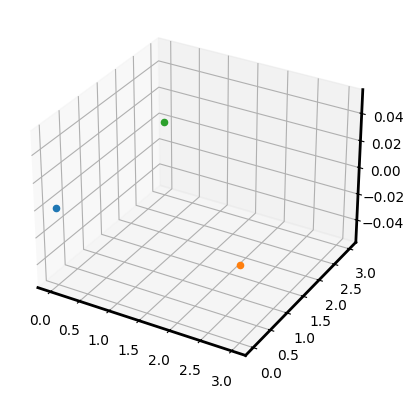

In [68]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
for fluorophore in fluorophore_system.fluorophores:
    ax.scatter(
        fluorophore.position[0],
        fluorophore.position[1],
        fluorophore.position[2],
        label=fluorophore.name,
    )

In [32]:
fluorophore_system = fl.FluorophoreSystem(
    fl.construct_fluorophores(name="cy5_dna", count=1)
)

In [20]:
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    summarize=True,
    energy_transfer=True,
    dstorm=True,
    irradiance=1e-4,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

In [50]:
simul = si.Simulation(transition_set)
simul.run()

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.69e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


In [51]:
emis = em.Emissions()
# emis.tcspc(
#     details=True,
#     transition_set=transition_set,
#     number_pulses=4e7,
#     store_time_points=True,
#     time_between_pulses=1e-6,
# )
emis.extract(simul)

In [ ]:
fc = fcs_p.FCS(emis)

In [53]:
fc.autocorrelate_time_points(exp_min=-10, exp_max=-5)

In [54]:
emis.event_time_points

array([1.23236064e-01, 1.87953722e-01, 2.02996432e-01, ...,
       5.10172466e+02, 5.10255467e+02, 5.10265455e+02], shape=(13190,))

In [55]:
np.min(np.diff(emis.event_time_points))

np.float64(1.8698504078429323e-06)

array([[<Axes: title={'center': '$\\tau_{min} = 1.39e-10$ s'}, xlabel='$\\tau \\ (s)$', ylabel='$G(\\tau)$'>]],
      dtype=object)

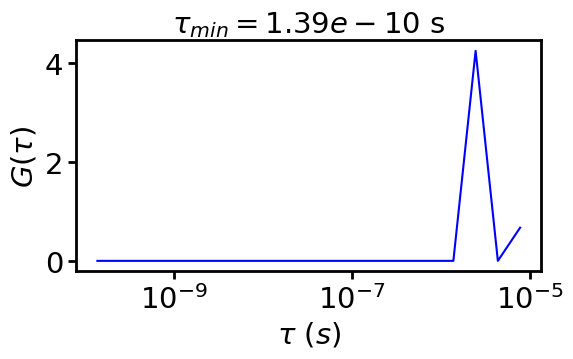

In [56]:
fc.plot()

In [33]:
_, _, _, simulation = Out[26]

In [35]:
hist, bins = fcs_p.coincidence(emis.event_time_points, 1e-6, 2e-10, 1)

In [36]:
emis2 = em.Emissions()
emis2.extract(simulation)

In [37]:
hist2, bins2 = fcs_p.coincidence(emis2.event_time_points, 1e-6, 2e-10, 1)

array([0.50746865, 0.55349206, 0.62482834, 0.71178836, 0.80262404,
       0.78142905, 0.70452151, 0.62228494, 0.55676214, 0.49232937])

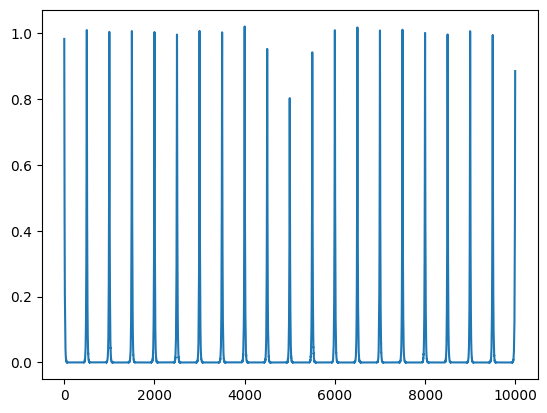

In [47]:
peaks, _ = find_peaks(hist, height=25)
normalize_to = hist[peaks[np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])]].mean()
normalized = hist / normalize_to
plt.plot(normalized)
normalized[4995:5005]

array([0.50746865, 0.55349206, 0.62482834, 0.71178836, 0.80262404,
       0.78142905, 0.70452151, 0.62228494, 0.55676214, 0.49232937])

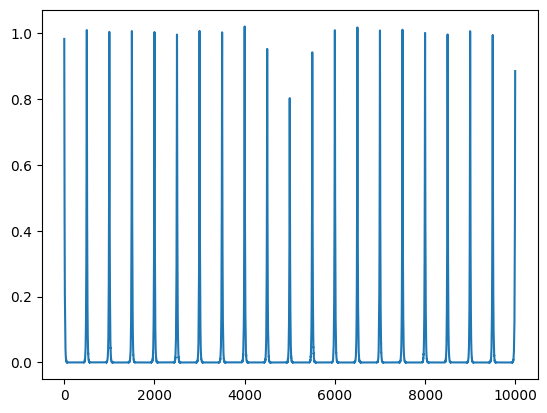

In [46]:
peaks, _ = find_peaks(hist2, height=25)
normalize_to = hist2[peaks[np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])]].mean()
normalized = hist2 / normalize_to
plt.plot(normalized)
normalized[4995:5005]